
<h1>
  <img src="https://upload.wikimedia.org/wikipedia/commons/c/c7/Google_Ads_logo.svg"
       width="40"
       style="vertical-align: middle;">
  Google Ads Sales Dataset Analysis
</h1>

<hr>

<h2>📝 1. Introduction / Overview</h2>
<p>
This project focuses on analyzing and cleaning an unstructured Google Ads sales dataset to prepare it for meaningful exploration and visualization.
The objective is to transform raw advertising data into a reliable and structured format for generating business and marketing insights.
</p>

<hr>

<h2>❓ 2. Problem Statement</h2>
<p>
The dataset contains missing values, inconsistent formats, incorrect data types, and potential anomalies, which affect the accuracy of the analysis.
These issues must be resolved to ensure reliable evaluation of campaign performance and return on investment.
</p>

<hr>

<h2>🎯 3. Aim & Objectives</h2>

<p><b>Aim:</b></p>
<ul>
  <li>✅ To clean, preprocess, and analyze Google Ads sales data for better marketing decision-making.</li>
</ul>

<p><b>Objectives:</b></p>
<ul>
  <li>📌 Identify and handle missing values</li>
  <li>📌 Remove duplicate and invalid records</li>
  <li>📌 Standardize and format campaign data</li>
  <li>📌 Convert incorrect data types</li>
  <li>📌 Perform exploratory data analysis (EDA)</li>
  <li>📌 Visualize key advertising and revenue trends</li>
  <li>📌 Calculate performance metrics such as CTR, CPC, and ROAS</li>
</ul>

<hr>

<h2>🗂 4. Dataset Description</h2>
<p>
The dataset is obtained from Kaggle and contains uncleaned Google Ads campaign records.
</p>
<p>
Total rows - 2600<br>
Total columns - 13
</p>
<h3>📑 Dataset Attributes</h3>

<ul>
  <li>🆔 <b>Ad_ID</b> –– Unique identifier assigned to each advertising campaign.</li>
  <li>📢 <b>Campaign_Name</b> –– Name of the campaign, containing typographical errors and naming variations.</li>
  <li>🖱️ <b>Clicks</b> –– Total number of clicks received by the advertisement.</li>
  <li>👁️ <b>Impressions</b> –– Number of times the advertisement was displayed to users.</li>
  <li>💰 <b>Cost</b> –– Total advertising cost, recorded in mixed currency formats (₹ / $) with missing values.</li>
  <li>📥 <b>Leads</b> –– Number of potential customers generated through the advertisement.</li>
  <li>✅ <b>Conversions</b> –– Number of successful actions such as sign-ups or purchases.</li>
  <li>📊 <b>Conversion_Rate</b> –– Calculated metric representing the ratio of conversions to clicks.</li>
  <li>💵 <b>Sale_Amount</b> –– Total revenue generated from successful conversions.</li>
  <li>📅 <b>Ad_Date</b> –– Date of ad activity, stored in inconsistent formats (e.g., YYYY/MM/DD, DD-MM-YY).</li>
  <li>📍 <b>Location</b> –– City where the advertisement was displayed, including spelling and case variations.</li>
  <li>📱 <b>Device</b> –– Type of device used by users (Mobile, Desktop, Tablet) with mixed casing.</li>
  <li>🔍 <b>Keyword</b> –– Search keyword that triggered the advertisement, containing typographical errors.</li>
</ul>
<hr>

## 🔃 1. Data Loading and Initial Overview

### Import Libraries

In [59]:
import pandas as pd
import numpy as np

### Loading Dataset

In [60]:
df = pd.read_csv("GoogleAds_DataAnalytics_Sales_Uncleaned.csv")
df.head()

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
0,A1000,DataAnalyticsCourse,104.0,4498.0,$231.88,14.0,7.0,0.058,$1892,2024-11-16,hyderabad,desktop,learn data analytics
1,A1001,DataAnalyticsCourse,173.0,5107.0,$216.84,10.0,8.0,0.046,$1679,20-11-2024,hyderabad,mobile,data analytics course
2,A1002,Data Anlytics Corse,90.0,4544.0,$203.66,26.0,9.0,NaN,$1624,2024/11/16,hyderabad,Desktop,data analitics online
3,A1003,Data Analytcis Course,142.0,3185.0,$237.66,17.0,6.0,NaN,$1225,2024-11-26,HYDERABAD,tablet,data anaytics training
4,A1004,Data Analytics Corse,156.0,3361.0,$195.9,30.0,8.0,NaN,$1091,2024-11-22,hyderabad,desktop,online data analytic


### Rows and Columns

In [61]:
print(f'Rows: {df.shape[0]}\nColumns: {df.shape[1]}')

Rows: 2600
Columns: 13


### Info

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ad_ID            2600 non-null   object 
 1   Campaign_Name    2600 non-null   object 
 2   Clicks           2488 non-null   float64
 3   Impressions      2546 non-null   float64
 4   Cost             2503 non-null   object 
 5   Leads            2552 non-null   float64
 6   Conversions      2526 non-null   float64
 7   Conversion Rate  1974 non-null   float64
 8   Sale_Amount      2461 non-null   object 
 9   Ad_Date          2600 non-null   object 
 10  Location         2600 non-null   object 
 11  Device           2600 non-null   object 
 12  Keyword          2600 non-null   object 
dtypes: float64(5), object(8)
memory usage: 264.2+ KB


#### Describe

In [63]:
df.describe()

,Clicks,Impressions,Leads,Conversions,Conversion Rate
count,2488.000000,2546.000000,2552.000000,2526.000000,1974.000000
mean,138.956994,4523.280833,20.003918,6.519002,0.048979
std,34.619376,869.927913,6.032317,2.272573,0.019987
min,80.000000,3000.000000,10.000000,3.000000,0.015000
25%,110.000000,3764.000000,15.000000,5.000000,0.035000
50%,139.000000,4518.500000,20.000000,7.000000,0.046000
75%,169.000000,5279.500000,25.000000,9.000000,0.058000
max,199.000000,5999.000000,30.000000,10.000000,0.123000


### Missing Values

In [64]:
df.isnull().sum()

Ad_ID                0
Campaign_Name        0
Clicks             112
Impressions         54
Cost                97
Leads               48
Conversions         74
Conversion Rate    626
Sale_Amount        139
Ad_Date              0
Location             0
Device               0
Keyword              0
dtype: int64

### Duplicate Rows

In [65]:
print("Duplicate count:", df.duplicated().sum())

Duplicate count: 0


### Data types

In [66]:
df.dtypes

Ad_ID               object
Campaign_Name       object
Clicks             float64
Impressions        float64
Cost                object
Leads              float64
Conversions        float64
Conversion Rate    float64
Sale_Amount         object
Ad_Date             object
Location            object
Device              object
Keyword             object
dtype: object

<hr>

## 🧹 2. Data Pre-processing

### 🔷 Text formatting

#### For 'Location' and 'Campaign_Name' only one value with typos, so replacing all unformatted values and standardizing with one value.

In [67]:
print('Location:',df['Location'].unique())
print('Campaign_Name:',df['Campaign_Name'].unique())

Location: ['hyderabad' 'HYDERABAD' 'Hyderbad' 'hydrebad']
Campaign_Name: ['DataAnalyticsCourse' 'Data Anlytics Corse' 'Data Analytcis Course'
 'Data Analytics Corse']


In [68]:
df['Location'] = 'Hyderabad'
df['Location'].unique()

array(['Hyderabad'], dtype=object)

In [69]:
df['Campaign_Name'] = 'Data Analytics Course'
df['Campaign_Name'].unique()

array(['Data Analytics Course'], dtype=object)

#### In the device column, no typos and only case mismatched so changing to a proper format.

In [70]:
df['Device'].unique()

array(['desktop', 'mobile', 'Desktop', 'tablet', 'MOBILE', 'TABLET',
       'Tablet', 'Mobile', 'DESKTOP'], dtype=object)

In [71]:
df['Device']= (df['Device'].astype(str).str.strip().str.title())
df['Device'].unique()

array(['Desktop', 'Mobile', 'Tablet'], dtype=object)

#### 'Keyword' column contains typos and improper formats, errors replaced and changed to proper format.

In [72]:
df['Keyword'].unique()

array(['learn data analytics', 'data analytics course',
       'data analitics online', 'data anaytics training',
       'online data analytic', 'analytics for data'], dtype=object)

In [73]:
df['Keyword'] = df['Keyword'].replace({'data analitics online':'data analytics online','data anaytics training':'data analytics training',
                                       'online data analytic':'online data analytics'})
df['Keyword'] = (df['Keyword'].astype(str).str.strip().str.title())
df['Keyword'].unique()

array(['Learn Data Analytics', 'Data Analytics Course',
       'Data Analytics Online', 'Data Analytics Training',
       'Online Data Analytics', 'Analytics For Data'], dtype=object)

#### For 'Sale_Amount' and 'Cost' columns there is a "$". So we remove them using str.replace() method

In [74]:
df['Sale_Amount'] = df['Sale_Amount'].str.replace("$","",regex=False).str.strip()
df['Cost'] = df['Cost'].str.replace("$","",regex=False).str.strip()

In [75]:
df.sample(5)

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
1097,A2097,Data Analytics Course,158.0,4574.0,198.9,21.0,8.0,NaN,1706,04-11-2024,Hyderabad,Desktop,Learn Data Analytics
950,A1950,Data Analytics Course,114.0,4333.0,192.81,26.0,6.0,0.053,1722,08-11-2024,Hyderabad,Tablet,Data Analytics Training
1523,A2523,Data Analytics Course,111.0,4164.0,191.04,18.0,9.0,NaN,1687,2024/11/21,Hyderabad,Tablet,Data Analytics Training
209,A1209,Data Analytics Course,130.0,3327.0,224.83,13.0,3.0,0.023,1668,16-11-2024,Hyderabad,Mobile,Online Data Analytics
756,A1756,Data Analytics Course,NaN,4373.0,199.32,16.0,5.0,NaN,1150,2024-11-02,Hyderabad,Desktop,Data Analytics Training


### 🔷 Changing Data types

In [76]:
df.dtypes

Ad_ID               object
Campaign_Name       object
Clicks             float64
Impressions        float64
Cost                object
Leads              float64
Conversions        float64
Conversion Rate    float64
Sale_Amount         object
Ad_Date             object
Location            object
Device              object
Keyword             object
dtype: object

#### Changing 'Cost' and 'Sale_Amount' columns to numeric data type

In [77]:
df['Cost'] = pd.to_numeric(df['Cost'], errors='coerce')
df['Sale_Amount'] = pd.to_numeric(df['Sale_Amount'], errors='coerce')

#### Changing Ad date to date format

In [78]:
df.head(10)

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
0,A1000,Data Analytics Course,104.0,4498.0,231.88,14.0,7.0,0.058,1892.0,2024-11-16,Hyderabad,Desktop,Learn Data Analytics
1,A1001,Data Analytics Course,173.0,5107.0,216.84,10.0,8.0,0.046,1679.0,20-11-2024,Hyderabad,Mobile,Data Analytics Course
2,A1002,Data Analytics Course,90.0,4544.0,203.66,26.0,9.0,NaN,1624.0,2024/11/16,Hyderabad,Desktop,Data Analytics Online
3,A1003,Data Analytics Course,142.0,3185.0,237.66,17.0,6.0,NaN,1225.0,2024-11-26,Hyderabad,Tablet,Data Analytics Training
4,A1004,Data Analytics Course,156.0,3361.0,195.90,30.0,8.0,NaN,1091.0,2024-11-22,Hyderabad,Desktop,Online Data Analytics
5,A1005,Data Analytics Course,195.0,3776.0,243.57,10.0,8.0,NaN,1315.0,16-11-2024,Hyderabad,Mobile,Data Analytics Training
6,A1006,Data Analytics Course,116.0,4480.0,237.79,17.0,5.0,0.043,1640.0,06-11-2024,Hyderabad,Tablet,Data Analytics Course
7,A1007,Data Analytics Course,184.0,5060.0,229.61,23.0,3.0,0.016,1509.0,2024/11/24,Hyderabad,Tablet,Analytics For Data
8,A1008,Data Analytics Course,113.0,5434.0,NaN,27.0,4.0,0.058,1362.0,2024/11/24,Hyderabad,Tablet,Data Analytics Training
9,A1009,Data Analytics Course,166.0,3355.0,186.78,24.0,9.0,0.054,1029.0,2024/11/12,Hyderabad,Mobile,Online Data Analytics


In [79]:
d1 = pd.to_datetime(df['Ad_Date'], format='%Y-%m-%d', errors='coerce')
d2 = pd.to_datetime(df['Ad_Date'], format='%d-%m-%Y', errors='coerce')
d3 = pd.to_datetime(df['Ad_Date'], format='%Y/%m/%d', errors='coerce')

df['Ad_Date'] = d1.fillna(d2).fillna(d3)

#### Date contains multiple formats, so used 3 formats to cover all senarios

In [80]:
df.dtypes

Ad_ID                      object
Campaign_Name              object
Clicks                    float64
Impressions               float64
Cost                      float64
Leads                     float64
Conversions               float64
Conversion Rate           float64
Sale_Amount               float64
Ad_Date            datetime64[ns]
Location                   object
Device                     object
Keyword                    object
dtype: object

### 🔷 Handling missing values

In [81]:
df.isnull().sum().sort_values(ascending=False)

Conversion Rate    626
Sale_Amount        139
Clicks             112
Cost                97
Conversions         74
Impressions         54
Leads               48
Ad_ID                0
Campaign_Name        0
Ad_Date              0
Location             0
Device               0
Keyword              0
dtype: int64

#### Missing values replaced using the mean of their respective device groups

In [82]:
# Average of Sale_Amount
df['Sale_Amount'] = df.groupby('Device')['Sale_Amount'].transform(lambda x: x.fillna(x.mean()).round(2))

# Average of Clicks
df['Clicks'] = df.groupby('Device')['Clicks'].transform(lambda x: x.fillna(x.mean()).round(2).round(2))

# Average of Cost
df['Cost'] = df.groupby('Device')['Cost'].transform(lambda x: x.fillna(x.mean()).round(2))

# Average of Conversions
df['Conversions'] = df.groupby('Device')['Conversions'].transform(lambda x: x.fillna(x.mean()).round(2))

# Average of Impressions
df['Impressions'] = df.groupby('Device')['Impressions'].transform(lambda x: x.fillna(x.mean()).round(2))

# Average of Leads
df['Leads'] = df.groupby('Device')['Leads'].transform(lambda x: x.fillna(x.mean()))


#### Now we replaced all empty values of all columns except 'Conversion Rate', this column is calculated trough a formula which is Conversion Rate = Conversions / Clicks. So we recalculate and fill missing Conversion Rate using this formula.

In [83]:
df['Conversion Rate'] = df['Conversions'] / df['Clicks']
df['Conversion Rate']  = df['Conversion Rate'].round(3)
df.isnull().sum()

Ad_ID              0
Campaign_Name      0
Clicks             0
Impressions        0
Cost               0
Leads              0
Conversions        0
Conversion Rate    0
Sale_Amount        0
Ad_Date            0
Location           0
Device             0
Keyword            0
dtype: int64

<hr>

## 🧮 3. Exploratory Data Analysis (EDA)

### ✅ Performance Metrics Analysis

#### Now evaluates campaign performance using three key metrics: Click-Through Rate (CTR), Cost Per Click (CPC) and Return on Ad Spend (ROAS). Analysis was conducted using statistical summaries and categorical grouping based on Device and Keyword.

### 1️⃣ Click-Through Rate (CTR)

#### Measures the proportion of users who clicked on an advertisement after viewing it.
##### CTR = Clicks ÷ Impressions

In [84]:
df['CTR'] = np.where(df['Impressions'] > 0,df['Clicks'] / df['Impressions'],np.nan)
df['CTR'] = df['CTR'].round(2)

### 2️⃣ Cost Per Click (CPC)

#### The average cost incurred for each user click.
##### CPC = Cost ÷ Clicks

In [85]:
df['CPC'] = np.where(df['Clicks']>0, df['Cost']/df['Clicks'],np.nan)
df['CPC'] = df['CPC'].round(2)

### 3️⃣ Return on Ad Spend (ROAS)

#### Measures revenue generated for every unit of advertising cost.
##### ROAS = Sale_Amount ÷ Cost

In [86]:
df['ROAS'] = np.where(df['Cost']>0, df['Sale_Amount']/df['Cost'],np.nan)
df['ROAS'] = df['ROAS'].round(2)

In [87]:
df.sample(5)

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword,CTR,CPC,ROAS
2036,A3036,Data Analytics Course,137.0,4189.0,208.84,17.0,6.59,0.048,1211.0,2024-11-09,Hyderabad,Mobile,Online Data Analytics,0.03,1.52,5.80
104,A1104,Data Analytics Course,89.0,3594.0,214.59,14.0,6.00,0.067,1026.0,2024-11-15,Hyderabad,Tablet,Data Analytics Course,0.02,2.41,4.78
1934,A2934,Data Analytics Course,83.0,4830.0,184.98,12.0,10.00,0.120,1041.0,2024-11-01,Hyderabad,Desktop,Learn Data Analytics,0.02,2.23,5.63
897,A1897,Data Analytics Course,164.0,3851.0,219.15,22.0,6.00,0.037,1487.0,2024-11-09,Hyderabad,Mobile,Learn Data Analytics,0.04,1.34,6.79
1694,A2694,Data Analytics Course,146.0,4624.0,212.67,19.0,9.00,0.062,1513.0,2024-11-09,Hyderabad,Mobile,Data Analytics Course,0.03,1.46,7.11


### ❌ Finding Outliers using IQR method

##### We will use 'Interquartile Range' method to identify outliers. It measures the spread of the middle 50% of the data.
##### Q1 (First Quartile) - 25th percentile and Q3 (Third Quartile) - 75th percentile
##### IQR = Q3 − Q1

In [88]:
columns_to_check = ['Clicks','Impressions','Cost','Leads','Conversions','Sale_Amount']
for col in columns_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    lower_limit = Q1 - 1.5*IQR
    upper_limit = Q3 + 1.5*IQR
    outliers = df[(df[col]<lower_limit) | (df[col]>upper_limit)]
    if not outliers.empty:
        print("Outliers found in column:", col)
    else:
        print("No outliers found in column:", col)

No outliers found in column: Clicks
No outliers found in column: Impressions
No outliers found in column: Cost
No outliers found in column: Leads
No outliers found in column: Conversions
No outliers found in column: Sale_Amount


#### With the help of a for loop, we checked the important columns for outliers and the result was no outliers found in the dataset.

### 1. Univariate Analysis

In [89]:
print("\nCTR Distribution\n",df['CTR'].describe())


CTR Distribution
 count    2600.000000
mean        0.032042
std         0.010615
min         0.010000
25%         0.020000
50%         0.030000
75%         0.040000
max         0.070000
Name: CTR, dtype: float64


In [90]:
print("\nCPC Distribution\n",df['CPC'].describe())


CPC Distribution
 count    2600.000000
mean        1.650235
std         0.462141
min         0.910000
25%         1.290000
50%         1.540000
75%         1.930000
max         3.090000
Name: CPC, dtype: float64


In [91]:
print("\nROAS Distribution\n",df['ROAS'].describe())


ROAS Distribution
 count    2600.000000
mean        7.027142
std         1.468967
min         4.070000
25%         5.890000
50%         6.940000
75%         8.100000
max        11.050000
Name: ROAS, dtype: float64


In [92]:
print("\nConversion Rate Distribution\n",df['Conversion Rate'].describe())


Conversion Rate Distribution
 count    2600.000000
mean        0.050035
std         0.022168
min         0.015000
25%         0.033000
50%         0.047000
75%         0.063000
max         0.125000
Name: Conversion Rate, dtype: float64


### 2. Bivariate Analysis

In [93]:
device_ctr = df.groupby('Device')['CTR'].agg(['mean', 'min', 'max', 'count'])
print("Device-wise CTR Analysis:\n", device_ctr)

Device-wise CTR Analysis:
              mean   min   max  count
Device                              
Desktop  0.031520  0.01  0.06    888
Mobile   0.032472  0.01  0.07    878
Tablet   0.032146  0.01  0.07    834


In [94]:
device_cpc = df.groupby('Device')['CPC'].agg(['mean', 'min', 'max', 'count'])
print("Device-wise CPC Analysis:\n", device_cpc)

Device-wise CPC Analysis:
              mean   min   max  count
Device                              
Desktop  1.664155  0.94  3.01    888
Mobile   1.648121  0.91  3.07    878
Tablet   1.637638  0.94  3.09    834


In [95]:
device_cvr = df.groupby('Device')['Conversion Rate'].agg(['mean', 'min', 'max', 'count'])
print("Device-wise Conversion Rate Analysis:\n", device_cvr)

keyword_cvr = df.groupby('Keyword')['Conversion Rate'].agg(['mean', 'min', 'max', 'count'])
print("\nKeyword-wise Conversion Rate Analysis:\n", keyword_cvr)

Device-wise Conversion Rate Analysis:
              mean    min    max  count
Device                                
Desktop  0.050786  0.015  0.122    888
Mobile   0.050425  0.015  0.120    878
Tablet   0.048824  0.015  0.125    834

Keyword-wise Conversion Rate Analysis:
                              mean    min    max  count
Keyword                                               
Analytics For Data       0.049068  0.016  0.125    429
Data Analytics Course    0.049675  0.015  0.119    440
Data Analytics Online    0.048657  0.015  0.120    420
Data Analytics Training  0.051024  0.015  0.122    414
Learn Data Analytics     0.051405  0.015  0.120    444
Online Data Analytics    0.050329  0.016  0.123    453


In [96]:
device_roas = df.groupby('Device')['ROAS'].agg(['mean', 'min', 'max', 'count'])
print("Device-wise ROAS Analysis:\n", device_roas)

keyword_roas = df.groupby('Keyword')['ROAS'].agg(['mean', 'min', 'max', 'count'])
print("\nKeyword-wise ROAS Analysis:\n", keyword_roas)

Device-wise ROAS Analysis:
              mean   min    max  count
Device                               
Desktop  7.052613  4.07  11.05    888
Mobile   6.977312  4.20  10.99    878
Tablet   7.052482  4.08  10.64    834

Keyword-wise ROAS Analysis:
                              mean   min    max  count
Keyword                                              
Analytics For Data       6.966270  4.21  10.84    429
Data Analytics Course    7.151023  4.08  11.05    440
Data Analytics Online    7.029810  4.13  10.83    420
Data Analytics Training  7.073720  4.13  10.96    414
Learn Data Analytics     7.063851  4.07  10.99    444
Online Data Analytics    6.883444  4.14  10.77    453


#### 📖 Findings:
##### The average of CTR and CPC seems to be almost the same across different devices, Desktop has the most count among them.
##### Conversion Rate is comparatively low on Tablet device.
##### For the ROAS, the average is a little less for the device Mobile. The highest average of ROAS and Conversion Rate among keywords is 'Data Analytics Course', and the lowest is 'Online Data Analytics'.

### 3. Multivariate Analysis

In [97]:
ctr = pd.pivot_table(df,values='CTR',index='Keyword',columns='Device',aggfunc=['mean'])
print("CTR vs Device & Keyword:\n", ctr)

CTR vs Device & Keyword:
                              mean                    
Device                    Desktop    Mobile    Tablet
Keyword                                              
Analytics For Data       0.030414  0.032207  0.030863
Data Analytics Course    0.032945  0.031600  0.032303
Data Analytics Online    0.033067  0.031136  0.032464
Data Analytics Training  0.030728  0.033113  0.031786
Learn Data Analytics     0.030949  0.032156  0.031929
Online Data Analytics    0.030775  0.034241  0.033333


In [98]:
cpc = pd.pivot_table(df,values='CPC',index='Keyword',columns='Device',aggfunc=['mean'])
print("CPC vs Device & Keyword:\n", cpc)

CPC vs Device & Keyword:
                              mean                    
Device                    Desktop    Mobile    Tablet
Keyword                                              
Analytics For Data       1.689517  1.585931  1.683957
Data Analytics Course    1.582393  1.654880  1.605066
Data Analytics Online    1.641400  1.665000  1.623043
Data Analytics Training  1.637285  1.637881  1.628482
Learn Data Analytics     1.728102  1.731018  1.657214
Online Data Analytics    1.723028  1.607911  1.629869


In [99]:
cvr = pd.pivot_table(df,values='Conversion Rate',index='Keyword',columns='Device',aggfunc=['mean'])
print("Conversion Rate vs Device & Keyword:\n", cvr)

Conversion Rate vs Device & Keyword:
                              mean                    
Device                    Desktop    Mobile    Tablet
Keyword                                              
Analytics For Data       0.051421  0.046676  0.049108
Data Analytics Course    0.049773  0.048696  0.050375
Data Analytics Online    0.047367  0.050591  0.048210
Data Analytics Training  0.053947  0.049656  0.048929
Learn Data Analytics     0.050927  0.055581  0.046893
Online Data Analytics    0.051415  0.050380  0.049268


In [100]:
roas = pd.pivot_table(df,values='ROAS',index='Keyword',columns='Device',aggfunc=['mean'])
print("ROAS vs Device & Keyword:\n", roas)

ROAS vs Device & Keyword:
                              mean                    
Device                    Desktop    Mobile    Tablet
Keyword                                              
Analytics For Data       6.920138  7.097034  6.877986
Data Analytics Course    7.236196  7.067600  7.128289
Data Analytics Online    6.996733  6.827879  7.258913
Data Analytics Training  7.103974  6.988344  7.148036
Learn Data Analytics     7.231460  6.941617  7.045643
Online Data Analytics    6.809014  6.948038  6.885817


#### 📖 Findings:
##### CTR - 'Data Analytics Online' keyword was better on all devices overall.'Online Data Analytics' keyword performed well on mobile devices, having the highest average.
##### CPC - 'Data Analytics Course' was the most cost-effective for getting clicks. 'Learn Data Analytics' was comparatively expensive to get the clicks.
##### Conversion Rate - Even though 'Learn Data Analytics' keyword was expensive, the conversion rate was a little better.
##### ROAS - 'Data Analytics Course' is also better at return on ad spend. The tablet device gave better returns than others. The least return given keyword was 'Online Data Analytics'.
##### The most cost-effective keyword gave better returns.

### Correlation

In [101]:
metrics_col = ['CTR','CPC','Conversion Rate','ROAS']
metrics_corr = df[metrics_col].corr()
metrics_corr

,CTR,CPC,Conversion Rate,ROAS
CTR,1.000000,-0.655267,-0.414090,0.013726
CPC,-0.655267,1.000000,0.571798,-0.164871
Conversion Rate,-0.414090,0.571798,1.000000,-0.019595
ROAS,0.013726,-0.164871,-0.019595,1.000000


##### CTR and CPC have a strong negative correlation (-0.655), indicating that higher CTR achieves lower CPC. CTR also has a moderate negative relationship with Conversion Rate (-0.414) shows higher clicks do not guarantee more conversions.
##### CPC and Conversion Rate show a moderate positive correlation (0.571), tells higher CPC may come from more valuable audiences.

<hr>

## 📈 4. Visualizations

#### Import Libraries

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

<h3><b>Ⅰ</b> <u>Univariate Analysis</u></h3> 

#### 1️⃣ Histogram – Click Distribution

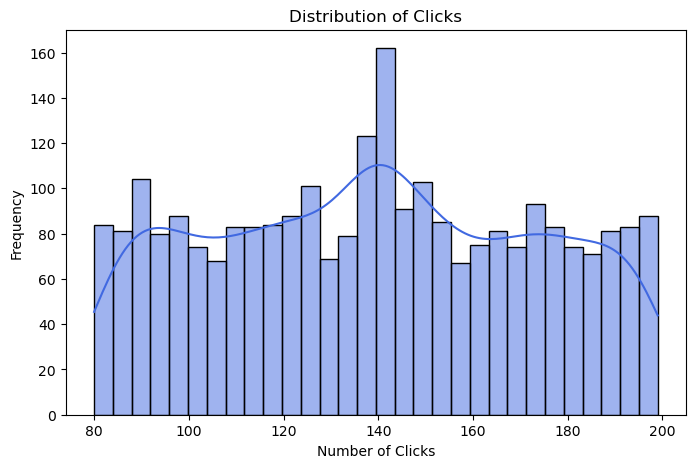

In [103]:
plt.figure(figsize=(8,5))
sns.histplot(df['Clicks'], bins=30, kde=True, color='royalblue')

plt.title('Distribution of Clicks')
plt.xlabel('Number of Clicks')
plt.ylabel('Frequency')

plt.show()

##### The histogram shows that the number of clicks per ad is fairly evenly distributed, centering around approximately 139 clicks. The distribution appears symmetric with no significant skewness or outliers, ranging from about 80 to 200 clicks. This indicates a consistent performance in terms of ad clicks across the dataset.

#### 2️⃣ Histogram – Advertising Cost Distribution

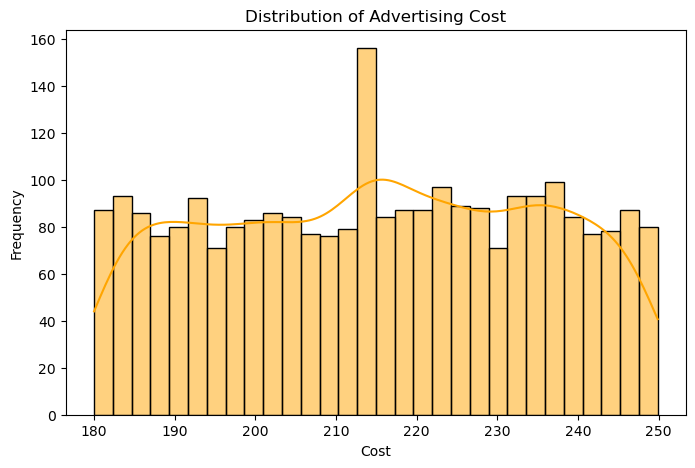

In [104]:
plt.figure(figsize=(8,5))
sns.histplot(df['Cost'], bins=30, kde=True, color='orange')

plt.title('Distribution of Advertising Cost')
plt.xlabel('Cost')
plt.ylabel('Frequency')

plt.show()

##### The histogram of advertising costs shows a relatively symmetric distribution, with a strong concentration around approximately 215. This indicates that many advertising records share similar cost values. The central spike may also be partially influenced by missing value imputation, where mean-based replacements cluster around the average cost.

### 3️⃣ Box Plot – Revenue Distribution

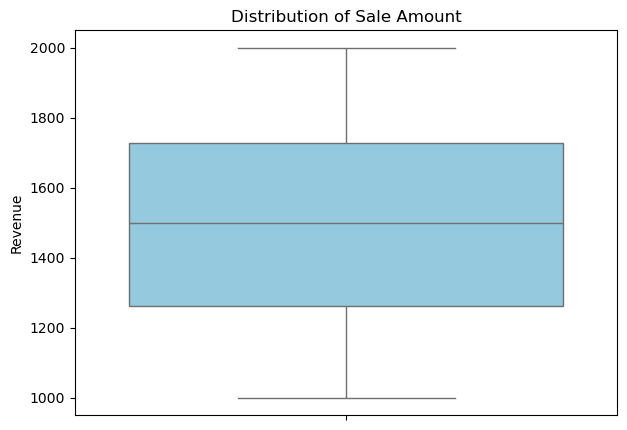

In [105]:
plt.figure(figsize=(7,5))

sns.boxplot(
    y=df['Sale_Amount'],
    color='skyblue'
)

plt.title('Distribution of Sale Amount')
plt.ylabel('Revenue')

plt.show()

##### The box plot for 'Sale Amount' shows a distribution without any detected outliers, indicating a consistent range of sales figures. The majority of sale amounts fall between approximately Q1 and Q3. The median sale amount is likely around the center of this range. The absence of outliers suggests a stable revenue performance across the dataset.

#### 4️⃣ Pie Chart — Device Distribution

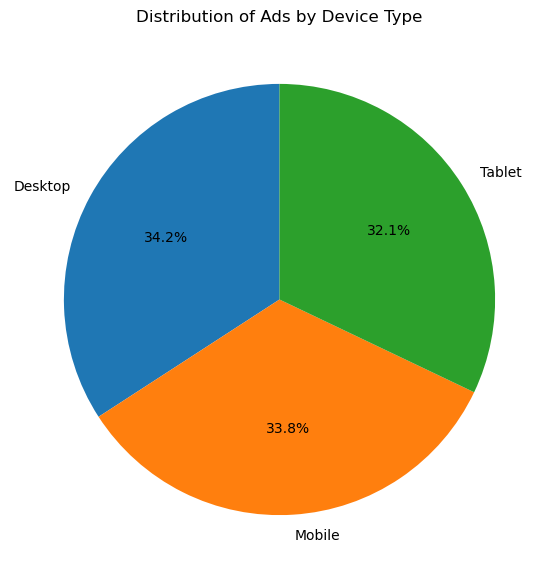

In [106]:
device_counts = df['Device'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    device_counts.values,
    labels=device_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Ads by Device Type')

plt.show()

##### The pie chart indicates that the distribution of ads across Desktop, Mobile, and Tablet devices is almost equal, with each device type representing roughly one-third of the total ads. This suggests a balanced advertising strategy across all platforms.

<h3><b>Ⅱ </b><u>Bivariate Analysis</u></h3> 

#### 5️⃣ Bar Plot – Clicks by Device

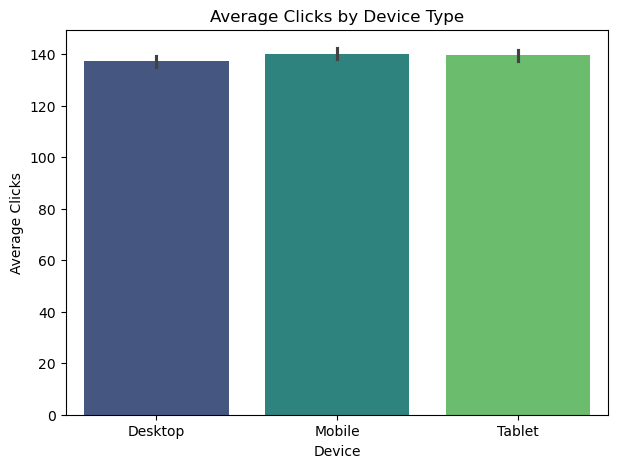

In [107]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x='Device',
    y='Clicks',
    estimator='mean',
    palette='viridis',
    hue='Device',
    legend=False
)

plt.title('Average Clicks by Device Type')
plt.xlabel('Device')
plt.ylabel('Average Clicks')

plt.show()

##### The visualization shows that there is no major difference in terms of average clicks across different device types (Desktop, Mobile, Tablet).

#### 6️⃣ Bar Plot – Conversions by Device

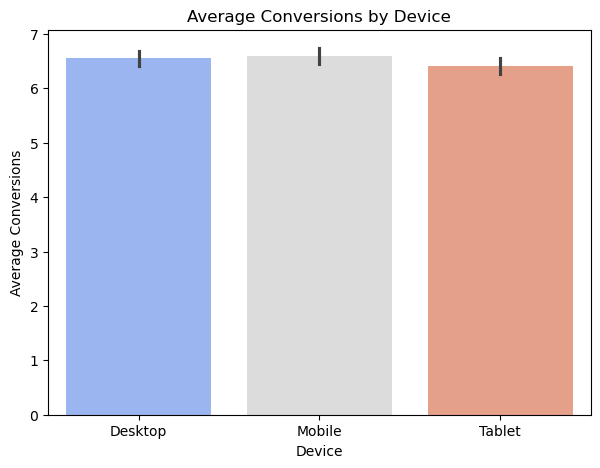

In [108]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x='Device',
    y='Conversions',
    estimator='mean',
    palette='coolwarm',
    hue='Device',
    legend=False
)

plt.title('Average Conversions by Device')
plt.xlabel('Device')
plt.ylabel('Average Conversions')

plt.show()

##### The visualization shows that Tablet devices have a slightly lower average conversion rate compared to Desktop and Mobile devices.

#### 7️⃣ Scatter Plot – Advertising Cost Over Time

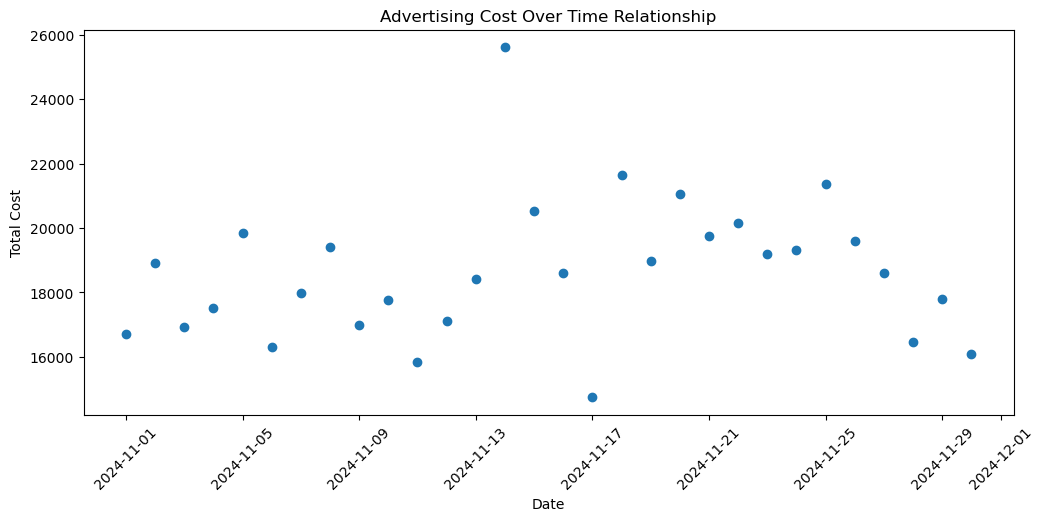

In [109]:
cost_trend = df.groupby('Ad_Date')['Cost'].sum().sort_index()

plt.figure(figsize=(12,5))

plt.scatter(
    cost_trend.index,
    cost_trend.values
)

plt.title('Advertising Cost Over Time Relationship')
plt.xlabel('Date')
plt.ylabel('Total Cost')
plt.xticks(rotation=45)

plt.show()

##### The scatter plot illustrates the total advertising cost over time. It generally shows consistent daily spending, with a notable significant spike in cost observed around November 14, 2024. This suggests that while daily expenditure is usually stable, there was a particular period with a substantially higher advertising investment.

#### 8️⃣ Bar Plot – Top Keywords by Clicks

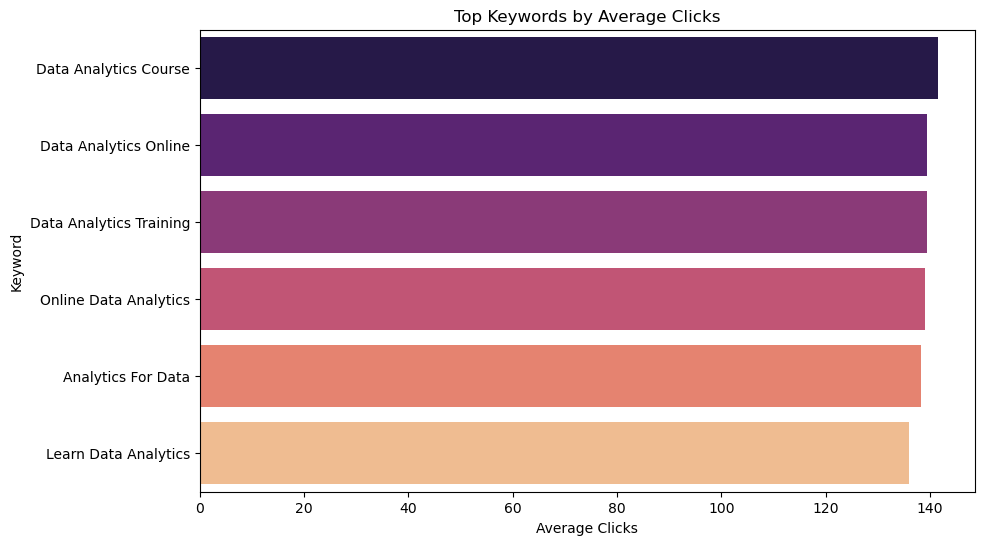

In [110]:
top_keywords = df.groupby('Keyword')['Clicks'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_keywords.values,
    y=top_keywords.index,
    palette='magma',
    hue=top_keywords.index,
    legend=False
)

plt.title('Top Keywords by Average Clicks')
plt.xlabel('Average Clicks')
plt.ylabel('Keyword')

plt.show()

##### The 'Data Analytics Course' keyword shows the highest average clicks, closely followed by 'Data Analytics Online'. 'Learn Data Analytics' has the lowest average clicks among all the keywords. Overall, the average clicks across all keywords are quite similar, suggesting no single keyword significantly outperforms the others in terms of drawing clicks.

#### 9️⃣ Box Plot – Revenue by Device

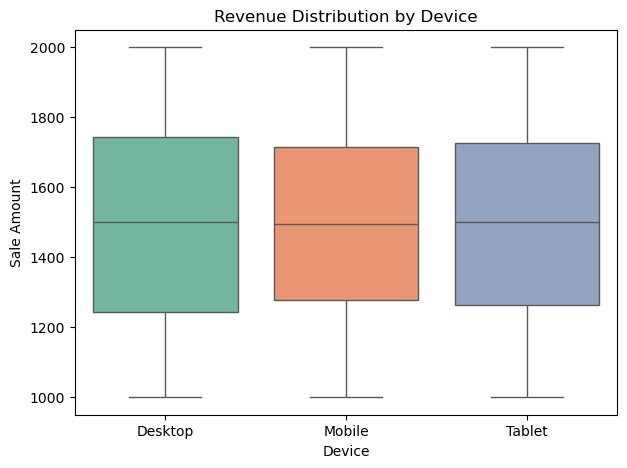

In [111]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='Device',
    y='Sale_Amount',
    palette='Set2',
    hue='Device',
    legend=False
)

plt.title('Revenue Distribution by Device')
plt.xlabel('Device')
plt.ylabel('Sale Amount')

plt.show()

##### The box plot for 'Revenue Distribution by Device' indicates that the sale amounts are quite consistent across Desktop, Mobile, and Tablet devices, showing no significant variation in revenue generated per sale among them.

#### 🔟 Line Chart - Conversions Trend Over Time

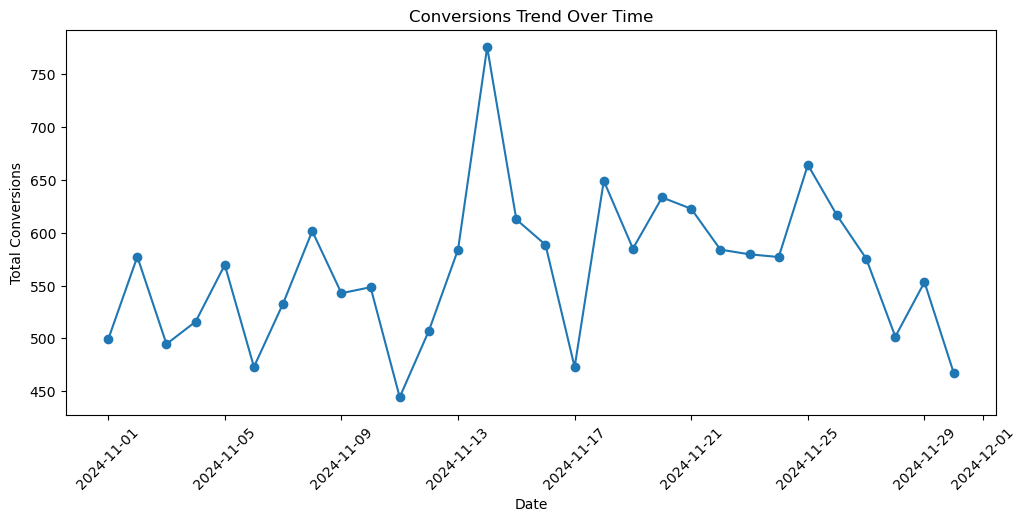

In [112]:
conversion_trend = df.groupby('Ad_Date')['Conversions'].sum().sort_index()

plt.figure(figsize=(12,5))

plt.plot(conversion_trend.index, conversion_trend.values, marker='o')

plt.title('Conversions Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Conversions')

plt.xticks(rotation=45)

plt.show()

##### The line chart displays the total conversions over time, showing daily fluctuations. A notable peak in conversions can be observed around November 14, 2024, similar to the advertising cost trend. Apart from this spike, the daily conversions generally remain consistent, indicating a stable conversion performance with occasional surges.

#### 1️⃣1️⃣ Interactive Scatter – Clicks vs Conversions

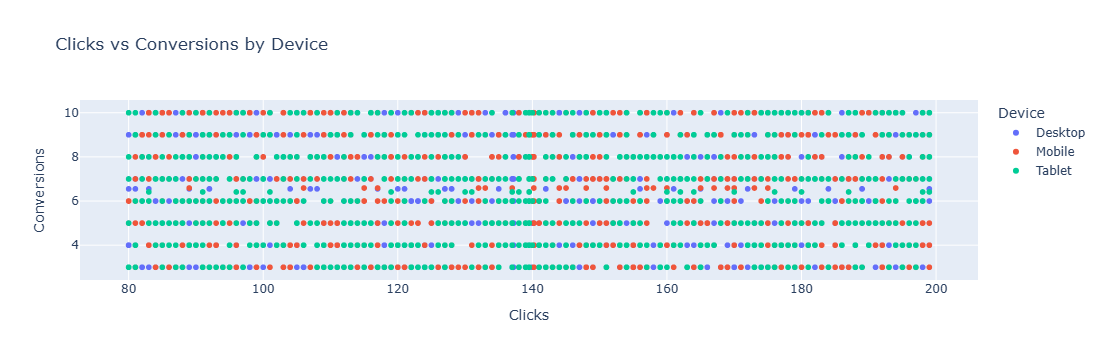

In [113]:
fig = px.scatter(
    df,
    x='Clicks',
    y='Conversions',
    color='Device',
    hover_data=['Keyword','Cost','Sale_Amount'],
    title='Clicks vs Conversions by Device'
)

fig.show()

##### This scatter plot illustrates the relationship between Clicks and Conversions, categorized by device type. The data points suggesting that no single device type consistently outperforms the others in terms of achieving significantly more conversions. The density of points indicates that most ad campaigns fall within similar ranges for both clicks and conversions.

<h3><b>Ⅲ </b><u>Multivariate Analysis</u></h3> 

#### 1️⃣2️⃣ Heatmap – Correlation Between Metrics

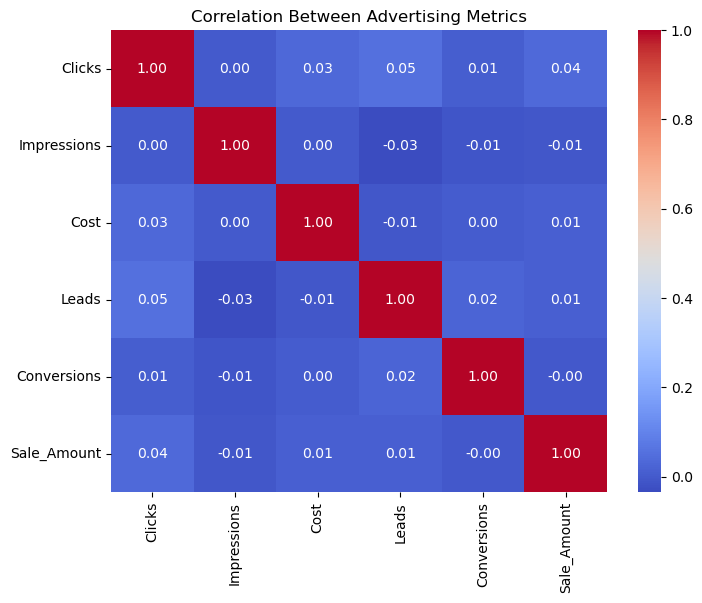

In [114]:
numeric_cols = ['Clicks','Impressions','Cost','Leads','Conversions','Sale_Amount']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title('Correlation Between Advertising Metrics')

plt.show()

##### The heatmap displays the correlation between various advertising metrics. We observe generally weak positive correlations across most pairs of metrics. Clicks show a very weak positive correlation with Impressions, Leads, Conversions, and Sale_Amount. Impressions have very little to no correlation with other metrics. Leads and Conversions, as well as Conversions and Sale_Amount, also show weak positive correlations. Overall, this indicating that improvements in one metric do not necessarily lead to proportional increases in others.

#### 1️⃣3️⃣ Interactive Bar – Keyword Performance

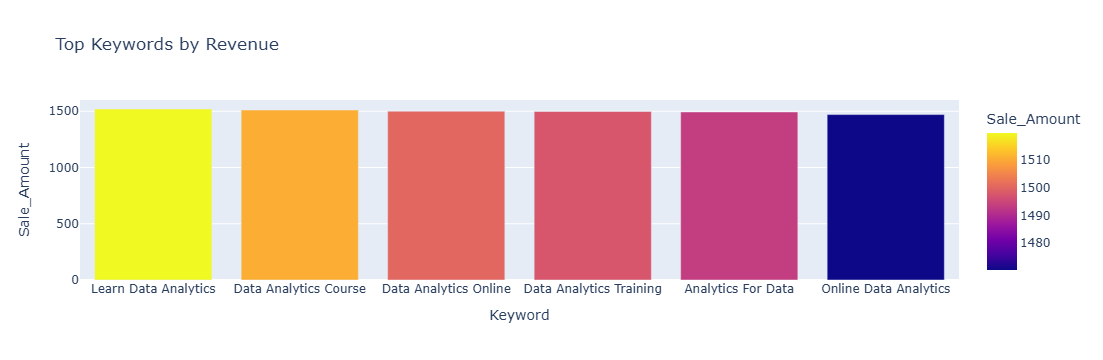

In [115]:
keyword_perf = df.groupby('Keyword')['Sale_Amount'].mean().sort_values(ascending=False).reset_index()

fig = px.bar(
    keyword_perf,
    x='Keyword',
    y='Sale_Amount',
    color='Sale_Amount',
    title='Top Keywords by Revenue'
)

fig.show()

##### The 'Learn Data Analytics' keyword generated the highest average revenue, indicating its strong performance in terms of sales. 'Online Data Analytics' yielded the lowest average revenue compared to other keywords. While there are differences, all keywords contribute significantly to revenue, with 'Learn Data Analytics' slightly leading the pack.


<hr>

## 📃 5. Documentation & Insights

### ⅰ) Executive Summary
This project focused on cleaning, preprocessing, and analyzing a Google Ads sales dataset to support data-driven marketing decisions. The objective was to transform raw advertising data into a structured format and evaluate campaign performance using key marketing metrics.

Key steps in the data preparation process included:
*   **Text Formatting**: Corrected typographical errors and inconsistent casing.
*   **Currency Formatting**: Removed currency symbols from Cost and Sale_Amount to enable numerical processing.
*   **Data Type Conversion**: Converted Cost and Sale_Amount to numeric values and standardized Ad_Date into datetime format.
*   **Handling Missing Values**: Missing values in columns such as Clicks, Cost, Conversions, Leads, Impressions, and Sale_Amount were imputed using the mean values within Device groups.
*   **Metric Recalculation**: The Conversion Rate column was recalculated using the cleaned Conversions and Clicks values.

These steps ensured the dataset was reliable and ready for accurate analysis and insight generation.

### ⅱ) Key Findings and Insights
The exploratory analysis revealed several important patterns related to advertising performance, keyword effectiveness, and device usage.

#### Performance Metric Distributions
*  **CTR (Click-Through Rate)**: Average of 0.032, ranging from 0.01 to 0.07, indicating relatively consistent engagement.
*  **CPC (Cost Per Click)**: Average 1.65, ranging from 0.91 to 3.09, suggesting stable click costs.
*  **Conversion Rate**: Average 0.050, ranging from 0.015 to 0.125, showing moderate variation in converting clicks into actions.
*  **ROAS (Return on Ad Spend)**: Average 7.03, ranging from 4.07 to 11.05, indicating strong overall campaign profitability.

#### Device-wise Performance
*  Advertising cost and clicks were distributed fairly evenly across Desktop, Mobile, and Tablet devices.
*  Tablet devices showed slightly lower conversion rates compared to Desktop and Mobile.
*  Revenue generation was generally similar across devices, with Desktop and Tablet showing slightly stronger in some cases.


#### Keyword-wise Performance
*  “Data Analytics Course” generated the highest average clicks and ROAS.
*  “Data Analytics Online” produced strong engagement but slightly lower returns.
*  “Learn Data Analytics” generated lower clicks but produced higher average revenue, suggesting valuable traffic despite higher CPC.

#### Correlation Insights
*  **CTR vs CPC**: Strong negative correlation (-0.655), meaning higher engagement tends to reduce cost per click.
*  **CTR vs Conversion Rate**: Moderate negative correlation (-0.414), indicating that more clicks do not always lead to proportionally more conversions.
*  **CPC vs Conversion Rate**: Moderate positive correlation (0.571), suggesting higher-cost clicks may attract more valuable audiences.

### ⅲ) Recommendations / Next Steps
Based on the analysis, several strategies can help improve advertising effectiveness and maximize return on investment.

#### 1. Keyword Strategy Optimization
*  Allocate more budget to high-performing keywords such as “Data Analytics Course.”
*  Review and optimize lower-performing keywords like “Online Data Analytics.”
*  Focus on keywords that produce higher ROAS and valuable conversions.

#### 2. Device Optimization
*  Investigate and improve tablet user conversion performance through better landing page optimization and user experience.
*  Continue monitoring Mobile performance, as it shows good overall performance.

#### 3. Budget and Bidding Strategy
*  Implement dynamic budget allocation based on performance trends.
*  Consider conversion-focused bidding strategies for keywords that attract high-value audiences.

#### 4. Ad Creative and Landing Page Optimization
*  Optimize landing pages to address the moderate negative correlation between CTR and Conversion Rate.
*  Regularly test different ad creatives, headlines, descriptions, and call-to-actions across devices and keywords.
*  Continuously monitor significant performance shifts, like the spike observed on November 14, 2024. Understand the underlying reasons for such spikes to replicate success or mitigate negative impacts.

### ⅳ) Overall Conclusion
The analysis demonstrates that the Google Ads campaign maintains stable performance across devices and keywords while generating strong returns on advertising spend. Data cleaning and preprocessing significantly improved data reliability, enabling meaningful analysis of key advertising metrics.

Key conclusions include:
*  Advertising costs and engagement levels remain relatively consistent across devices.
*  Certain keywords generate stronger engagement and revenue performance.
*  Higher CPC values may indicate more valuable audiences likely to convert.
*  Temporal spikes in spending and conversions may reflect specific promotional events.

By leveraging these findings and implementing the recommended strategies, businesses can improve advertising efficiency, allocate budgets more effectively, and maximize return on investment (ROI) in future campaigns.

<hr>